In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_anthropic import ChatAnthropic
from langgraph.graph.message import add_messages
from dotenv import load_dotenv

from langgraph.prebuilt import ToolNode, tools_condition
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool

import requests
import random

d:\ARTIFICIAL INTELLIGENCE\Agentic-AI-using-LangGraph\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\DELL\AppData\Local\Temp\ipykernel_22080\2591608289.py:9: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchRun


In [2]:
load_dotenv()

True

In [3]:
llm = ChatAnthropic(model="claude-haiku-4-5-20251001")

In [4]:
# Tools
search_tool = DuckDuckGoSearchRun(region="us_en")

@tool
def calculator(first_num: float, second_num: float, operation: str) -> dict:
    """
    Perform a basic arithmetic operation on two numbers.
    Supported operations: add, sub, mul, div
    """
    try:
        if operation == "add":
            result = first_num + second_num
        elif operation == "sub":
            result = first_num - second_num
        elif operation == "mul":
            result = first_num * second_num
        elif operation == "div":
            if second_num == 0:
                return {"error": "Division by zero is not allowed."}
            result = first_num / second_num
        else:
            return {"error": f"Unsupported operation: {operation}"}
        
        return {"first_num": first_num, "second_num": second_num, "operation": operation, "result": result}

    except Exception as e:
        return {"error": str(e)}
    
@tool
def get_stock_price(symbol: str) -> dict:
    """
    Fetch latest stock price for a given symbol (e.g. 'AAPL', 'TSLA')
    using Alpha Vantage with API key in the URL.
    """
    url = f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={symbol}&apikey=IR66B4CSLXFE7FTT"
    r = requests.get(url)
    return r.json()

In [5]:
# Make tool list
tools = [get_stock_price, search_tool, calculator]

# Make the LLM tool-aware
llm_with_tools = llm.bind_tools(tools)

In [6]:
# state
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [7]:
# graph nodes
def chat_node(state: ChatState):
    """LLM node that may answer or request a tool call."""
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

tool_node = ToolNode(tools)     # Executes tool calls

In [8]:
# graph structures
graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_node)
graph.add_node("tools", tool_node)

In [9]:
graph.add_edge(START, "chat_node")

# If the LLM asked for a tool, go to ToolNode; else finish
graph.add_conditional_edges("chat_node", tools_condition)

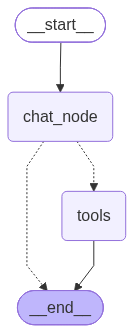

In [10]:
chatbot = graph.compile()

chatbot

In [11]:
# Regular chat
out = chatbot.invoke({"messages": [HumanMessage(content="Hello!")]})

print(out["messages"][-1].content)

Hello! 👋 How can I help you today? 

I have access to several tools that I can use to assist you:

- **Stock Price Lookup** - Get the latest stock price for any symbol (e.g., AAPL, TSLA)
- **Web Search** - Find current information and news
- **Calculator** - Perform arithmetic calculations

Feel free to ask me anything you'd like help with!


In [12]:
# Chat requiring tool
out = chatbot.invoke({"messages": [HumanMessage(content="What is 2*3?")]})
print(out["messages"][-1].content)

{"first_num": 2.0, "second_num": 3.0, "operation": "mul", "result": 6.0}


In [13]:
# Chat requiring tool
out = chatbot.invoke({"messages": [HumanMessage(content="What is the stock price of apple")]})
print(out["messages"][-1].content)

{"Global Quote": {"01. symbol": "AAPL", "02. open": "333.5050", "03. high": "333.7100", "04. low": "323.6800", "05. price": "326.5900", "06. volume": "53468008", "07. latest trading day": "2026-07-20", "08. previous close": "333.7400", "09. change": "-7.1500", "10. change percent": "-2.1424%"}}


In [14]:
# Chat requiring tool
out = chatbot.invoke({"messages": [HumanMessage(content="What is the stock price of Apple. How much would it cost to buy 50 shares?")]})
print(out["messages"][-1].content)

{"Global Quote": {"01. symbol": "AAPL", "02. open": "333.5050", "03. high": "333.7100", "04. low": "323.6800", "05. price": "326.5900", "06. volume": "53468008", "07. latest trading day": "2026-07-20", "08. previous close": "333.7400", "09. change": "-7.1500", "10. change percent": "-2.1424%"}}


In [15]:
# graph structures
graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_node)
graph.add_node("tools", tool_node)

In [16]:
graph.add_edge(START, "chat_node")

# If the LLM asked for a tool, go to ToolNode; else finish
graph.add_conditional_edges("chat_node", tools_condition)

graph.add_edge("tools", "chat_node")

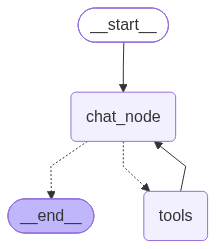

In [17]:
chatbot = graph.compile()

chatbot

In [18]:
# Chat requiring tool
out = chatbot.invoke({"messages": [HumanMessage(content="What is 2*3?")]})
print(out["messages"][-1].content)

2 × 3 = **6**


In [19]:
# Chat requiring tool
out = chatbot.invoke({"messages": [HumanMessage(content="What is the stock price of apple")]})
print(out["messages"][-1].content)

Based on the latest data, **Apple (AAPL)** stock price is:

- **Current Price**: $326.59
- **Latest Trading Day**: July 20, 2026
- **Change**: -$7.15 (-2.14%)
- **Open**: $333.51
- **High**: $333.71
- **Low**: $323.68
- **Volume**: 53,468,008 shares

The stock is down 2.14% from the previous close of $333.74.


In [20]:
# Chat requiring tool
out = chatbot.invoke({"messages": [HumanMessage(content="What is the stock price of Apple. How much would it cost to buy 50 shares?")]})
print(out["messages"][-1].content)

**Apple (AAPL) Stock Information:**

- **Current Price:** $326.59 per share
- **Latest Trading Day:** July 20, 2026
- **Change:** -$7.15 (-2.14%) from previous close

**Cost to Buy 50 Shares:**
- **Total Cost:** $16,329.50

So if you were to purchase 50 shares of Apple at the current price, it would cost you approximately $16,329.50.
